In [3]:
import pandas as pd
import missingno

enc = 'utf-8'

In [4]:
df_economics = pd.read_csv('../data/GR_EUROSTAT_Economics_Raw.csv', encoding=enc)
df_economics

,DATAFLOW,LAST UPDATE,freq,unit,geo,TIME_PERIOD,OBS_VALUE,OBS_FLAG
0,ESTAT:NAMA_10R_3GDP(1.0),21/02/23 23:00:00,A,EUR_HAB,AL,2008,3000.0,NaN
1,ESTAT:NAMA_10R_3GDP(1.0),21/02/23 23:00:00,A,EUR_HAB,AL,2009,3000.0,NaN
2,ESTAT:NAMA_10R_3GDP(1.0),21/02/23 23:00:00,A,EUR_HAB,AL,2010,3100.0,NaN
3,ESTAT:NAMA_10R_3GDP(1.0),21/02/23 23:00:00,A,EUR_HAB,AL,2011,3200.0,NaN
4,ESTAT:NAMA_10R_3GDP(1.0),21/02/23 23:00:00,A,EUR_HAB,AL,2012,3300.0,NaN
...,...,...,...,...,...,...,...,...
253539,ESTAT:NAMA_10R_3GDP(1.0),21/02/23 23:00:00,A,PPS_HAB_EU27_2020,TRC34,2017,30.0,NaN
253540,ESTAT:NAMA_10R_3GDP(1.0),21/02/23 23:00:00,A,PPS_HAB_EU27_2020,TRC34,2018,28.0,NaN
253541,ESTAT:NAMA_10R_3GDP(1.0),21/02/23 23:00:00,A,PPS_HAB_EU27_2020,TRC34,2019,30.0,NaN
253542,ESTAT:NAMA_10R_3GDP(1.0),21/02/23 23:00:00,A,PPS_HAB_EU27_2020,TRC34,2020,31.0,NaN


In [5]:
df_economics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253544 entries, 0 to 253543
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   DATAFLOW     253544 non-null  object 
 1   LAST UPDATE  253544 non-null  object 
 2   freq         253544 non-null  object 
 3   unit         253544 non-null  object 
 4   geo          253544 non-null  object 
 5   TIME_PERIOD  253544 non-null  int64  
 6   OBS_VALUE    253544 non-null  float64
 7   OBS_FLAG     18995 non-null   object 
dtypes: float64(1), int64(1), object(6)
memory usage: 15.5+ MB


In [6]:
df_economics.freq.unique()

array(['A'], dtype=object)

In [7]:
df_economics.DATAFLOW.unique()

array(['ESTAT:NAMA_10R_3GDP(1.0)'], dtype=object)

In [8]:
df_economics['LAST UPDATE'].unique()

array(['21/02/23 23:00:00'], dtype=object)

In [9]:
df_economics.unit.unique()

array(['EUR_HAB', 'EUR_HAB_EU27_2020', 'MIO_EUR', 'MIO_NAC',
       'MIO_PPS_EU27_2020', 'PPS_EU27_2020_HAB', 'PPS_HAB_EU27_2020'],
      dtype=object)

In [10]:
df_economics.TIME_PERIOD.unique()

array([2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018,
       2019, 2020, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2021],
      dtype=int64)

In [57]:
nuts3 = df_economics.geo.unique()

In [11]:
df_economics_gr = df_economics.query("geo.str.match('EL\d{3}')").copy()

In [13]:
df_economics_gr = df_economics_gr[df_economics_gr.unit == 'MIO_EUR'].copy()

In [16]:
df_economics_gr.drop(columns=['DATAFLOW', 'LAST UPDATE', 'freq', 'unit', 'OBS_FLAG'], inplace=True)

In [17]:
df_economics_gr.reset_index(drop=True, inplace=True)

In [18]:
df_economics_gr

,geo,TIME_PERIOD,OBS_VALUE
0,EL301,2000,10002.35
1,EL301,2001,10677.52
2,EL301,2002,12022.34
3,EL301,2003,12784.96
4,EL301,2004,14149.98
...,...,...,...
1087,EL653,2016,3040.69
1088,EL653,2017,3112.33
1089,EL653,2018,3111.77
1090,EL653,2019,3210.42


In [19]:
df_out = df_economics_gr.rename(columns={"geo": "NUTS3_CODE", "TIME_PERIOD": "YEAR", "OBS_VALUE": "MIO_EUR"}, errors="raise")

<AxesSubplot:>

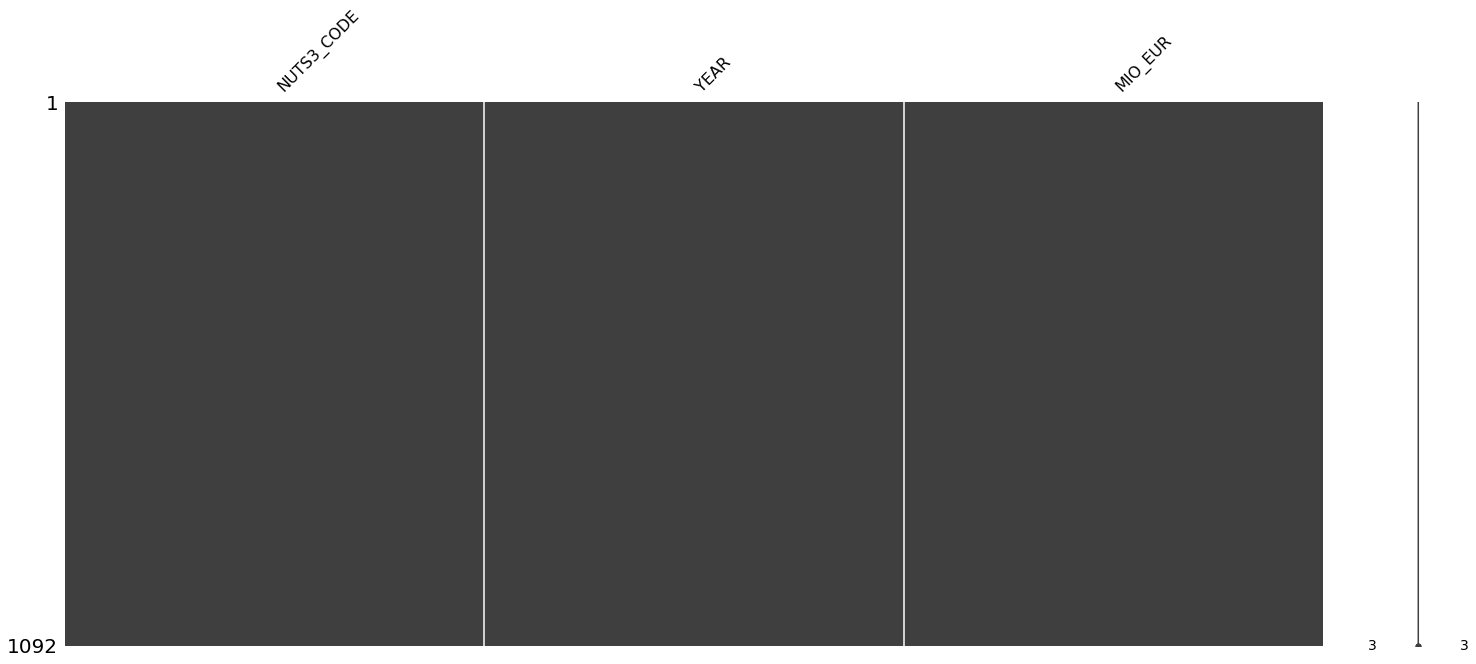

In [20]:
missingno.matrix(df_out)

In [21]:
df_out.to_csv('../data/GR_EUROSTAT_Economics_Processed.csv', index=False)